**YOUR NAME HERE**

CS 251/2: Data Analysis and Visualization

Spring 2026

Project 3: Clustering

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import kmeans

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5)


# Automatically reload external modules
%load_ext autoreload
%autoreload 2

## Task 2: Image Quantization

In this task, you will apply K-means to one image and to quantize it (*this is a version of the image with fewer colors, and fewer colors allows image formats to compress the images*). The idea is that you will find $k$ RGB color centroids in the image, then replace each pixel in the image with the nearest centroid. The resulting picture  will use only $k$ colors to represent it. You can also think of this as doing a simple image region segmentation: regions with similar colors will belong to the same cluster. It also makes some cool retro effects!

### 2a. Load in frog image

1. Use the imported `imread` method below to load in the `frog.jpg` image.
2. Use `plt.imshow` to display it in the notebook below. Turn off plot ticks!

In [2]:
from matplotlib.image import imread

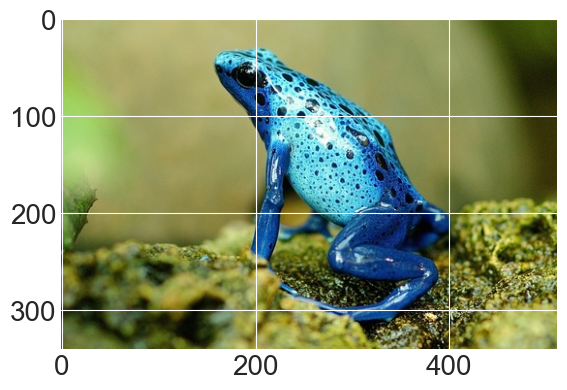

In [27]:
# YOUR CODE HERE

img = np.array(imread("assets/frog.jpg"))
plt.imshow(img)

### 2b. Preprocess image

In the two cells below:
1. Fill in the function below to collapse (flatten) the 2D image into a big 1D vector of RGB values. For example, for the frog image, your function should take the shape `(num_rows, num_cols, rgb)` and convert it to `(num_rows*num_cols, rgb)`.
2. Reshape the frog image from `(num_rows, num_cols, rgb)` and convert it to `(num_rows*num_cols, rgb)`.

In [13]:
def flatten(img):
    '''Flattens `img` to N 1D vectors.
    For example, for an RGB image, `(num_rows, num_cols, rgb)` -> `(num_rows*num_cols, rgb)`.

    Parameters:
    -----------
    img: ndarray. shape=(num_rows, num_cols, rgb)

    Returns:
    -----------
    Flattened `img`. ndarray. shape=(num_rows*num_cols, rgb)
    '''
    # YOUR CODE HERE
    num_rows, num_cols, rgb = img.shape
    
    return img.reshape(num_rows * num_cols, rgb)
    

In [15]:
# YOUR CODE HERE
frog_flat = flatten(img)

#### Test frog image shape

In [21]:
print(f'The shape of your frog image after flattening is\n{frog_flat.shape}')
print('and it should be\n(174592, 3)')

The shape of your frog image after flattening is
(174592, 3)
and it should be
(174592, 3)


### 2c. Cluster RGB values in image

1. Run K-means on the flattened frog image. Cluster the image so that the quantized/clustered image will have only 3 colors.
2. Implement `replace_color_with_centroid`: replace every pixel in the image with the nearest centroid RGB value.
3. Quantize the image by running `replace_color_with_centroid`.

In [ ]:
# YOUR CODE HERE
cluster_frog = kmeans.KMeans(frog_flat)
cluster_frog.cluster(k=3)
cluster_frog.replace_color_with_centroid()

In [ ]:
# YOUR CODE HERE
frog_quantisized = cluster_frog.get_data()

### 2d. Postprocessing and visualization

Reshape the quantized image data back to its original dimensions and cast the ndarray so that it stores ints.

Plot the quantized image below.

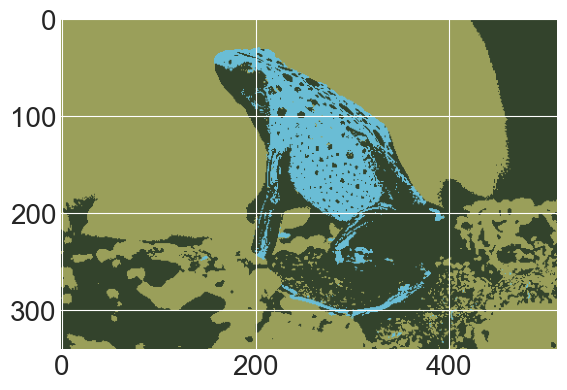

In [28]:
# YOUR CODE HERE
reshaped_frog = frog_quantisized.reshape(img.shape).astype(int)
plt.imshow(reshaped_frog)

### 2e. Run K-means and quantize an image of your choice

Smaller images run a lot faster.

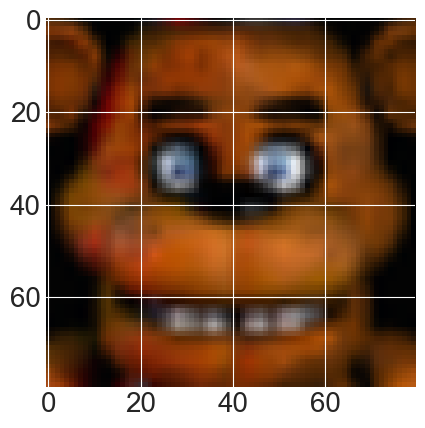

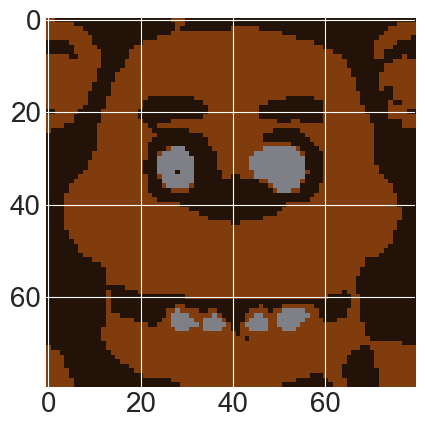

In [39]:
# YOUR CODE HERE
freddy_img = np.array(imread("assets/FREDDY.png"))[:, :, :3]
plt.imshow(freddy_img)
flat_freddy = flatten(freddy_img)
cluster_freddy = kmeans.KMeans(flat_freddy)
cluster_freddy.cluster(3)
cluster_freddy.replace_color_with_centroid()
quantisized_data = cluster_freddy.get_data()
reshaped_freddy = quantisized_data.reshape(freddy_img.shape)
plt.figure()
plt.imshow(reshaped_freddy)

## Task 3: Image region segmentation

The goal is to apply K-means to a colorized map of world continents (sans Antarctica) and segment out each continent in its own image.

### 3a. Load in and visualize world map

Load and view `world_map_small.png` in the cell below using matplotlib.

*As with the images in the previous task, turn off ticks and any other visual clutter.*

(np.float64(-0.5), np.float64(709.5), np.float64(327.5), np.float64(-0.5))

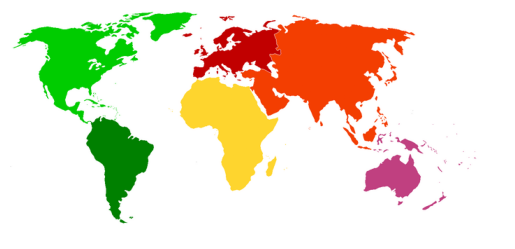

In [42]:
# YOUR CODE HERE
world = np.array(imread("assets/world_map_small.png"))
plt.imshow(world)
plt.axis("off")

### 3b. Implement and test the `segment_cluster` method in the `Kmeans` class

#### Test: `segment_cluster`

Run the following test multiple times and make sure it always looks correct.

In [44]:
test_data = np.vstack([np.zeros([1, 5]), np.ones([1, 5]), 3*np.ones([1, 5]), 2*np.ones([1, 5]), np.ones([1, 5])])
print('Test data looks like:')
print(test_data)
test_km = kmeans.KMeans(test_data)
test_km.cluster(k=2)
test_km.replace_color_with_centroid()
seg_data = test_km.segment_cluster(k=0)
print('There should be only 0s in following rows:', np.flatnonzero(test_km.get_data_centroid_labels()))
print(seg_data)

Test data looks like:
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [3. 3. 3. 3. 3.]
 [2. 2. 2. 2. 2.]
 [1. 1. 1. 1. 1.]]
There should be only 0s in following rows: [0 1 4]
[[0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0. ]
 [2.5 2.5 2.5 2.5 2.5]
 [2.5 2.5 2.5 2.5 2.5]
 [0.  0.  0.  0.  0. ]]


### 3c. Use K-means to segment the world map image

Use K-means and your segmentation method to show 6 separate images below, each with only one colored continent. You should select a number of clusters that allows you to reliably segment the continents.

**Notes:**
- It is fine if North and South America appear in the same plot (in which case you only need to generate 5 images).
- It is fine if faint outlines of other continents are included in a segment continent in solid color.
- Before you segment, it might be helpful to view your quantized image to visualize the clusters.
- The segmented color of each continent might be slightly different from the original based on what the centroids are.

In [66]:
np.random.seed(0)  # KEEP ME

# YOUR CODE HERE
world = np.array(imread("assets/world_map_small.png"))
world_flat = flatten(world)
cluster_world = kmeans.KMeans(world_flat)
cluster_world.cluster_batch(k=6, n_iter=20)
cluster_world.replace_color_with_centroid()

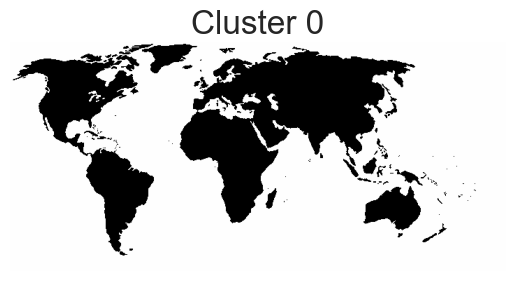

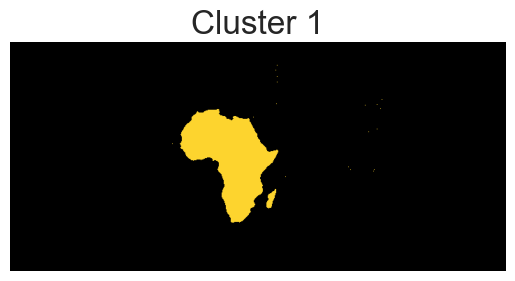

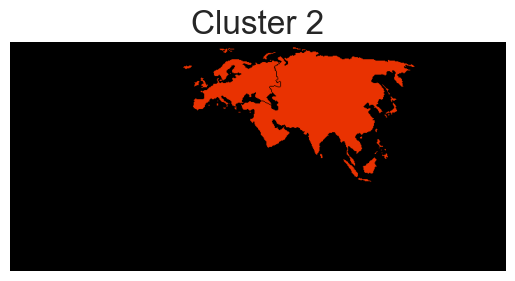

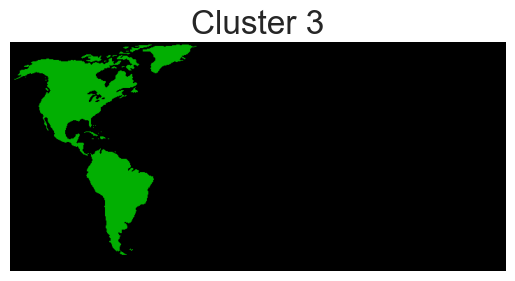

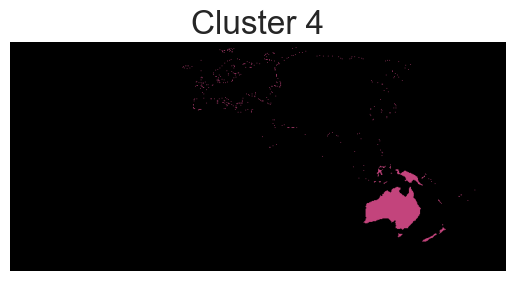

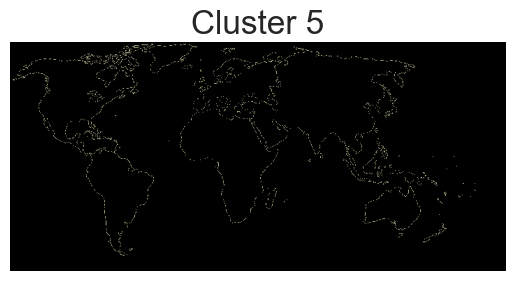

In [65]:
# YOUR CODE HERE
for i in range(cluster_world.k):
    seg = cluster_world.segment_cluster(i)
    seg_img = seg.reshape(world.shape)
    seg_img = (seg_img * 255).astype(int)

    plt.figure()
    plt.imshow(seg_img)
    plt.axis('off')
    plt.title(f'Cluster {i}')
    plt.show()